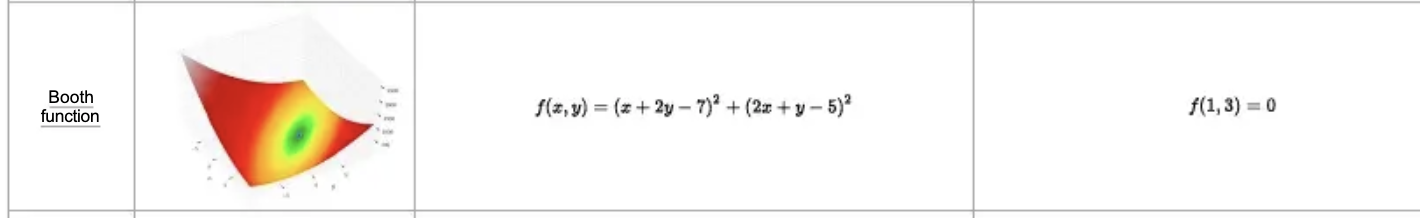

Взяти одну тестову функцію з джерела та реалізувати для неї генетичний алгоритм, який знаходить екстремум такої функції. Показати візуальну роботу даного алгоритму на обраній функції.

f(x, y) = (x + 2y - 7)^2 + (2x + y - 5)^2. 
Мінімум: f(1, 3) = 0

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm
import time
from IPython import display 

In [31]:
def booth_function(x, y):
    return (x + 2 * y - 7)**2 + (2 * x + y - 5)**2

size_of_population = 50       
count_of_gen = 100 
percant_of_mut = 0.1 
person_without_mut = 2   
d_1 = [-10, 10]
d_2 = [-10, 10]

population = np.random.uniform(low=[d_1[0], d_2[0]], 
                               high=[d_1[1], d_2[1]], 
                               size=(size_of_population, 2))

history_of_our_country = []

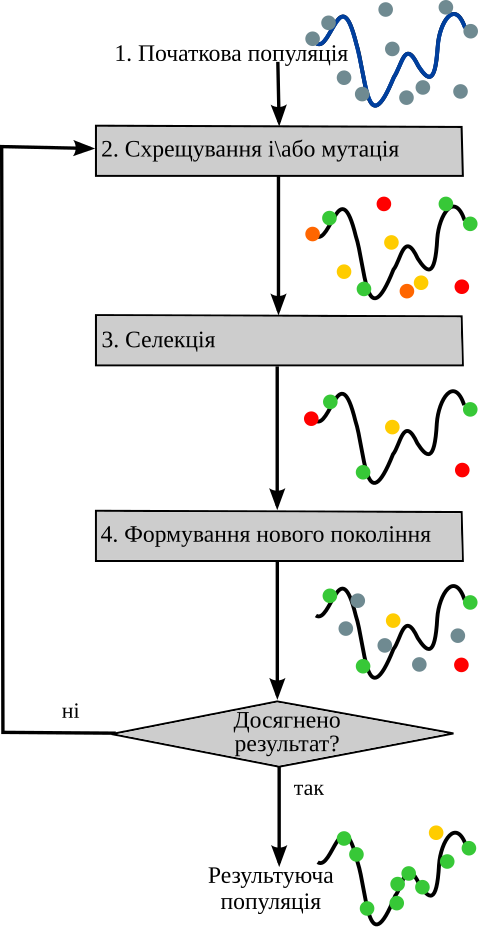

In [32]:
def fitness(individual):
    return -booth_function(individual[0], individual[1])

Roulette wheel selection is a method in genetic algorithms where individuals are chosen to reproduce based on their fitness, with fitter individuals having a higher probability of being selected.

In [33]:
def select(pop, fits):
    min_fit = np.min(fits)
    positive_fits = fits - min_fit + 1e-6 
    probabilities = positive_fits / np.sum(positive_fits)
    idx = np.random.choice(np.arange(len(pop)), size=size_of_population, replace=True, p=probabilities)
    return pop[idx]

def crossover(parent1, parent2):
    alpha = np.random.rand()
    child = alpha * parent1 + (1 - alpha) * parent2
    return child

def mutate(child):
    if np.random.rand() < percant_of_mut:
        child += np.random.normal(0, 0.5, size=2)
    return np.clip(child, [d_1[0], d_2[0]], [d_1[1], d_2[1]])

In [34]:
x_plot = np.linspace(-5, 5, 200) 
y_plot = np.linspace(-5, 5, 200)
X, Y = np.meshgrid(x_plot, y_plot)
Z = booth_function(X, Y)

fig = plt.figure(figsize=(12, 6))
ax1 = fig.add_subplot(121, projection='3d')
ax2 = fig.add_subplot(122)

ax1.plot_surface(X, Y, np.clip(Z, 0, 100), cmap=cm.viridis, alpha=0.6) 
sc = ax1.scatter([], [], [], c='yellow', s=50, label="Популяція")
ax1.set_xlabel('x'); ax1.set_ylabel('y'); ax1.set_zlabel('f(x, y)')
ax1.set_title('Еволюція')
ax1.view_init(elev=20, azim=130) # 
ax1.set_zlim(0, 100) 


line, = ax2.plot(range(count_of_gen), [0]*count_of_gen, color='blue')
ax2.axhline(0, color='red', linestyle='--', linewidth=1, label='Глобальний мінімум')
ax2.set_title('Графік збіжності')
ax2.set_xlabel('Покоління'); ax2.set_ylabel('Найкраще f(x, y)')
ax2.set_yscale('log')
ax2.grid(True, which="both", ls="--")
ax2.legend()

plt.tight_layout()

<IPython.core.display.Javascript object>

/var/folders/7y/jzj3rvbx3875_q5lqczlj3x00000gn/T/ipykernel_20613/559960245.py:22: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  ax2.set_yscale('log')


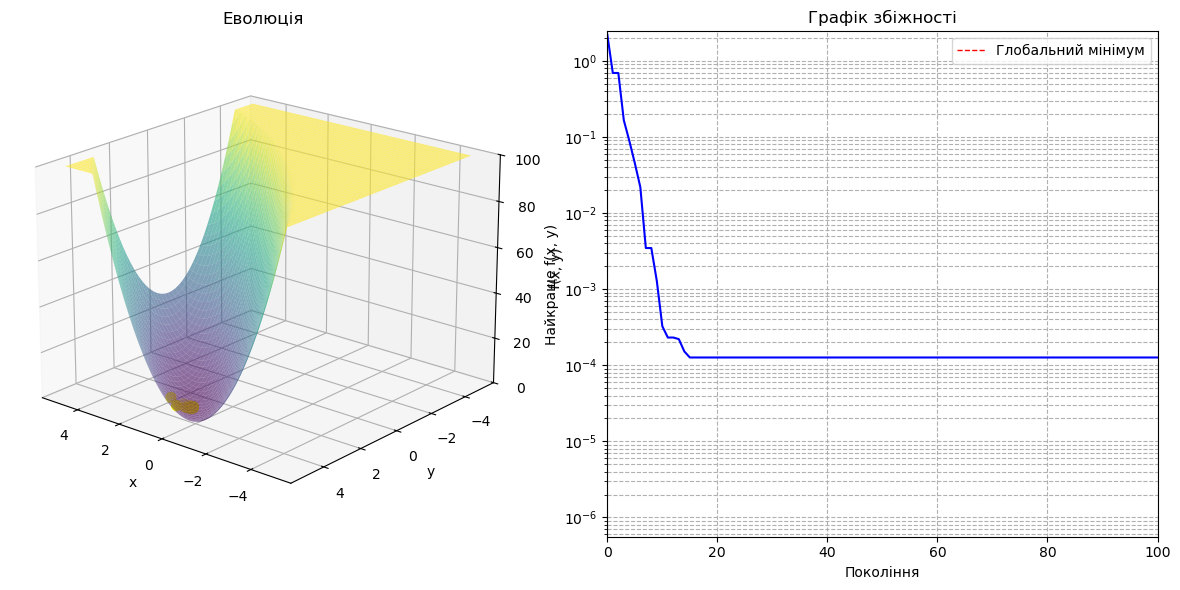

In [41]:
for generation in range(count_of_gen):
    values = np.array([booth_function(ind[0], ind[1]) for ind in population])
    fits = np.array([-v for v in values])
    

    best_idx = np.argmin(values)
    best_individual = population[best_idx]
    best_value = values[best_idx]
    
    history_of_our_country.append(best_value)

    elete = np.argsort(values)[:person_without_mut]
    eletisme = population[elete]

    parents = select(population, fits)
    
    next_gen = []
    for i in range(0, size_of_population, 2):
        parent1, parent2 = parents[i], parents[(i + 1) % size_of_population]
        
        child1 = crossover(parent1, parent2)
        child2 = crossover(parent2, parent1)
        
        next_gen.append(mutate(child1))
        next_gen.append(mutate(child2))
        
    next_gen = np.array(next_gen)

    population = np.copy(next_gen) 
    population[size_of_population - person_without_mut:] = eletisme

    if generation % 5 == 0 or generation == count_of_gen - 1:
        display.clear_output(wait=True)
        z_coords = booth_function(population[:, 0], population[:, 1])
        sc._offsets3d = (population[:, 0], population[:, 1], z_coords)
        

        line.set_ydata(history_of_our_country)
        line.set_xdata(range(len(history_of_our_country)))
        ax2.set_xlim(0, count_of_gen)
        
        epsilon = 1e-10
        y_min_safe = np.maximum(np.min(history_of_our_country), epsilon)
        ax2.set_ylim(y_min_safe, np.max(history_of_our_country) * 1.1)
        
        plt.suptitle(f'Покоління {generation}/{count_of_gen}: f(x,y) = {best_value:.6f}', fontsize=14)
        display.display(fig) 
  
        time.sleep(0.05) 

display.clear_output(wait=True) 

final_values = np.array([booth_function(ind[0], ind[1]) for ind in population])
best_idx = np.argmin(final_values)
pop_the_best = population[best_idx]

display.display(fig) 

In [36]:
print(f"Мінімум точки: x={pop_the_best[0]:.5f}, y={pop_the_best[1]:.5f}")
print(f"Розвʼязок чисельна збіжність {final_values[best_idx]:.5f}")

Мінімум точки: x=1.00763, y=2.99182
Розвʼязок чисельна збіжність 0.00013
